# Required Functions

In [119]:
import seaborn as sns
import matplotlib
from matplotlib import pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import pandas as pd
import json
import re
sns.set()

In [120]:
def load_dataframe(filename):
    with open(filename,'r') as f:
        df = pd.DataFrame(json.load(f))
        df['index'] = range(len(df))
        return df

def drop_cols(df,dropcols):
    return df[list(filter(lambda x:not re.search('|'.join(dropcols),x) ,df.columns))]

def plot_pie_chart(df,dropcols,dropre=['min','max','avg'],index=0,ax_elem=None):
    if ax_elem is None:
        print('ERROR: pass an axis element')
        return
    df = df.drop(dropcols,axis=1)
    df = drop_cols(df,dropre)
    dfi = df.loc[str(index),:]
    ax_elem.axis('equal')
    labels = [ '-'.join(list(map(str,item))) for item in list(dfi.items())]
    ax_elem.pie(dfi, labels=labels,startangle=0)

def save_figs_as_pdf(fig_arr,filename):
    with PdfPages(filename) as pdf:
        for fig in fig_arr:
            pdf.savefig(fig)
            
def list_detections(output):
    dets_d = {}
    for ko in output.keys():
        d = output[ko]
        dets = []
        for k in d.keys():
            dc = d[k]
            dets.append(dc['output']['labels_detected'])
        dets_d[ko]=dets
    return dets_d

def sort_index(df):
    df.index = list(map(int,df.index))
    df.sort_index(inplace=True)
    df.index = list(map(str,df.index))
    
def count_elems(dct):
    count = {}
    sums = {}
    for k in dct.keys():
        count[k] = list(map(lambda l:len(l) ,dct[k]))
        sums[k] = sum(count[k])
    return count,sums

def read_dict(jsonfile):
    op = {}
    with open(jsonfile,'r') as f:
        op = json.load(f)
    return op

def rc(data,digits=4):
    return round(data,digits)

def round_cols(df,cols,digits=4):
    df.loc[:,cols] = df.loc[:,cols].apply(rc)
    return df

def get_intervals_data(intervals_dicts):
    its = list(map(read_dict,intervals_dicts))
    return its

def get_info_what_key(dct,key):
    for i in dct.keys():
        d = dct[i]
        for k in d.keys():
            if d[k]['key']==key:
                return k

def detections_count(ints_dm):
    detcount={}
    for f in ints_dm.keys():
        detcount[f]=sum(ints_dm[f][1])
    return detcount

def get_int_info(dct):
    res = {}
    for i in dct.keys():
        d = dct[i]
        res[i]={}
        for k in d.keys():
            key = d[k]['key']
            res[i][key]=[d[k]['info'],d[k]['success']]
            #res[i][key]['what']=k
    return res

def info_det(dct):
    res = {}
    for i in dct.keys():
        res[i] = dct[i]['detect']
    return res

def merge_intervals_info(detector_intervals):
    rj = {}
    for k in detector_intervals.keys():
        d = detector_intervals[k]
        rj[k]={'post_detection_ops':d['post_detection_ops'][0],'success':d['post_detection_ops'][1],'detect':d['detect'][0]}
    return rj

def cpy_det_sucess_data(detector_intervals_merged,ints_dm):
    for k in ints_dm.keys():
        ints_dm[k][1] = detector_intervals_merged[k]['success']
    return ints_dm

def plot_data_for_file(data_ex,ints_ex,ints_dm,file_index = 0,cols_to_drop=['name','index','input_file','Total_time','video_duration','video_file_size']):
    file_index = str(file_index)
    print('Plotting data for performance of',data_ex.loc[file_index]['name'],'on',data_ex.loc[file_index]['input_file'])
    fig, axes = plt.subplots(2,2,figsize=(20,20))
    pie_ax,lax,oax1,oax2=axes.reshape(-1,1)
    plt.subplots_adjust(wspace=0.4)
    plt.close(fig)
    pie_ax = pie_ax[0];oax1 = oax1[0];oax2 = oax2[0];lax=lax[0];
    
    df = pd.DataFrame()
    det_count = ints_dm[file_index][1]
    time_taken_per_frame_ex = ints_ex[file_index][0]
    time_taken_per_frame_dm = ints_dm[file_index][0]
    
    #pie chart
    plot_pie_chart(data_ex,cols_to_drop,index=file_index,ax_elem=pie_ax)
    
    #contour X(det count) vs time taken(multiple Y) for dm_detect and ex_detect
    df = pd.DataFrame()
    df['number of detections'] = det_count
    df['time taken per frame - detector model'] = time_taken_per_frame_dm
    df['time taken per frame - overall'] = time_taken_per_frame_ex
    #sns.jointplot("number of detections", "time taken per frame - detector model", data=df, height=5, ratio=6, color="black", kind="kde", space=0,shade=True)
    sns.lineplot(x="number of detections",y= "time taken per frame - detector model", data=df,ax=oax1)
    sns.lineplot(x="number of detections",y= "time taken per frame - overall", data=df,ax=oax2)
    #running X (ith frame) , det count, time_dm,time_ex,
    dfdm = pd.DataFrame()
    dfdm['number of detections'] = det_count
    dfdm['time taken per frame'] = time_taken_per_frame_dm
    dfdm['type'] = 'detector model'
    dfdm['frame'] = list(range(len(dfdm)))
    dfex = pd.DataFrame()
    dfex['number of detections'] = det_count
    dfex['time taken per frame'] = time_taken_per_frame_ex
    dfex['type'] = 'overall'
    dfex['frame'] = list(range(len(dfex)))
    df = dfdm.append(dfex)
    sns.lineplot(x="frame",y="time taken per frame",style="type", data=df,ax=lax)
    return fig

# Fetch & Load Data

In [121]:
df_files = ['detection_model-time.json','extractor-time.json']
output_data_dict_file = 'output_data.json' 
intervals_dicts = ['ext-intervals_data.json','det-intervals_data.json']

In [122]:
drop_columns = False
drop_re=['min','max'] #drop all columns that have these words
cols_to_round = ['video_duration','detect-avg']
cols_to_drop = ['name','index','input_file','Total_time','video_duration','video_file_size']

dfs = list(map(load_dataframe,df_files))
if drop_columns:
    dfs = list(map(lambda d:drop_cols(d,drop_re),dfs))

dfs = list(map(lambda d:round_cols(d,cols_to_round),dfs))
data_dm,data_ex = dfs 
#dfex - DataFrame of extractor (main program)
#dfdm - DataFrame of Detector model
output_dict = read_dict(output_data_dict_file)
#detections_lst = list_detections(output_dict)

#detections_count, detections_sum = count_elems(detections_lst)

dts = list(map(get_int_info,get_intervals_data(intervals_dicts)))
ints_ex,ints_dm = list(map(info_det,dts)) #intervals data
detector_intervals_merged = merge_intervals_info(dts[1])
ints_dm = cpy_det_sucess_data(detector_intervals_merged,ints_dm)

sort_index(data_ex)
sort_index(data_dm)

num_detections = list(map(int,detections_count(ints_dm)))
data_dm['num_detections']=num_detections
data_ex['num_detections']=num_detections


#important takeaways:
#ints_dm and ints_ex, detections_count, data_dm,data_ex

# Inspect Data

In [123]:
print(data_ex.columns,'\n',data_dm.columns)

Index(['Total_time', 'download_video', 'detect-avg', 'name', 'input_file',
       'fetch_frame-max', 'fetch_frame-total', 'load_video_file', 'load_model',
       'detect-max', 'detect-total', 'init&prepare_model', 'fetch_frame-min',
       'save_annotations', 'fetch_frame-avg', 'detect-min', 'video_duration',
       'video_file_size', 'index', 'num_detections'],
      dtype='object') 
 Index(['detect-avg', 'name', 'post_detection_ops-total', 'input_file',
       'post_detection_ops-max', 'post_detection_ops-min',
       'post_detection_ops-avg', 'load_model', 'detect-max', 'import_deps',
       'detect-total', 'init_model', 'video_duration', 'detect-min',
       'video_file_size', 'index', 'num_detections'],
      dtype='object')


## DataFrame from extractor (main program)

In [124]:
data_ex #DataFrame of extractor (main program)

,Total_time,download_video,detect-avg,name,input_file,fetch_frame-max,fetch_frame-total,load_video_file,load_model,detect-max,detect-total,init&prepare_model,fetch_frame-min,save_annotations,fetch_frame-avg,detect-min,video_duration,video_file_size,index,num_detections
0,121.5066,1.9931,0.2673,yolo,Best Goals Of 2018.mp4,0.2786,35.6719,0.0092,7.5289,0.3026,74.0332,0.0918,0.0285,1.9957,0.1288,0.2527,277.4438,45.0,0,10
1,93.7916,2.1827,0.1768,detectron,Best Goals Of 2018.mp4,0.2654,35.6446,0.0077,4.6238,0.4693,48.9779,0.0295,0.0233,2.1449,0.1287,0.1639,277.4438,45.0,1,11
2,151.2730,2.0124,0.2885,yolo,Why is 0! = 1.mp4,0.2028,34.0733,0.0102,7.2182,0.3226,105.0231,0.0948,0.0182,2.4998,0.0936,0.2671,364.7644,14.0,4,1
3,123.2227,2.0741,0.2677,yolo,Cristiano Ronaldo Goals where Goalkeepers Dont...,0.2379,32.7448,0.0097,7.3058,0.3064,78.1736,0.0906,0.0179,2.6955,0.1121,0.2567,292.4800,43.0,5,0
4,94.0209,1.9401,0.1776,detectron,Cristiano Ronaldo Goals where Goalkeepers Dont...,0.2927,33.1939,0.0099,4.7539,0.4358,51.8590,0.0305,0.0175,2.1055,0.1137,0.1614,292.4800,43.0,6,3
5,76.5654,1.7320,0.2907,yolo,Yuvi 6 sixes full HD.mp4,0.2146,16.4733,0.0074,7.3651,0.3366,49.7092,0.0925,0.0237,0.9439,0.0963,0.2712,171.8800,20.0,7,2
6,53.8868,1.5842,0.1759,detectron,Yuvi 6 sixes full HD.mp4,0.2116,16.7544,0.0087,4.2995,0.4668,30.0798,0.0296,0.0285,0.8592,0.0980,0.1652,171.8800,20.0,8,5
7,122.1283,2.3980,0.2612,yolo,Marc Raibert shows off a close-to-production S...,0.2806,37.4119,0.0173,7.2222,0.3048,72.6007,0.0930,0.0326,2.1359,0.1346,0.2531,278.5118,52.0,9,4
8,96.5051,2.3323,0.1773,detectron,Marc Raibert shows off a close-to-production S...,0.3064,38.4826,0.0198,4.3271,0.4799,49.3010,0.0275,0.0344,1.7620,0.1384,0.1693,278.5118,52.0,10,7
9,152.2797,2.2487,0.2607,yolo,Cristiano Ronaldo UCL Goals That Shocked The W...,0.2710,45.8105,0.0120,8.0748,0.3231,93.0781,0.0917,0.0227,2.6667,0.1283,0.2527,357.7240,55.0,11,6


## DataFrame from Detector model

In [125]:
data_dm #DataFrame of Detector model

,detect-avg,name,post_detection_ops-total,input_file,post_detection_ops-max,post_detection_ops-min,post_detection_ops-avg,load_model,detect-max,import_deps,detect-total,init_model,video_duration,detect-min,video_file_size,index,num_detections
0,0.0286,yolo,11.5737,Best Goals Of 2018.mp4,0.0487,0.0387,0.0418,7.5207,0.0320,0.0760,7.9138,0.0154,277.4438,0.0274,45.0,0,10
1,0.1689,detectron,2.1553,Best Goals Of 2018.mp4,0.0100,0.0061,0.0078,4.6190,0.4611,0.0293,46.7744,NaN,277.4438,0.1573,45.0,1,11
2,0.0292,yolo,15.5789,Why is 0! = 1.mp4,0.0495,0.0394,0.0428,7.2110,0.0313,0.0780,10.6110,0.0164,364.7644,0.0277,14.0,4,1
3,0.0284,yolo,11.9852,Cristiano Ronaldo Goals where Goalkeepers Dont...,0.0484,0.0374,0.0410,7.2978,0.0312,0.0749,8.2994,0.0154,292.4800,0.0275,43.0,5,0
4,0.1696,detectron,2.2792,Cristiano Ronaldo Goals where Goalkeepers Dont...,0.0102,0.0057,0.0078,4.7482,0.4277,0.0303,49.5283,NaN,292.4800,0.1555,43.0,6,3
5,0.0289,yolo,7.0845,Yuvi 6 sixes full HD.mp4,0.0472,0.0379,0.0414,7.3565,0.0310,0.0766,4.9495,0.0156,171.8800,0.0276,20.0,7,2
6,0.1684,detectron,1.2538,Yuvi 6 sixes full HD.mp4,0.0098,0.0058,0.0073,4.2945,0.4592,0.0294,28.7969,NaN,171.8800,0.1591,20.0,8,5
7,0.0283,yolo,11.2838,Marc Raibert shows off a close-to-production S...,0.0483,0.0383,0.0406,7.2142,0.0309,0.0766,7.8813,0.0160,278.5118,0.0275,52.0,9,4
8,0.1692,detectron,2.2149,Marc Raibert shows off a close-to-production S...,0.0106,0.0063,0.0080,4.3216,0.4696,0.0273,47.0367,NaN,278.5118,0.1615,52.0,10,7
9,0.0283,yolo,14.6135,Cristiano Ronaldo UCL Goals That Shocked The W...,0.0495,0.0376,0.0409,8.0654,0.0310,0.0757,10.0984,0.0156,357.7240,0.0274,55.0,11,6


# Plot Data

Plotting data for performance of yolo on Best Goals Of 2018.mp4


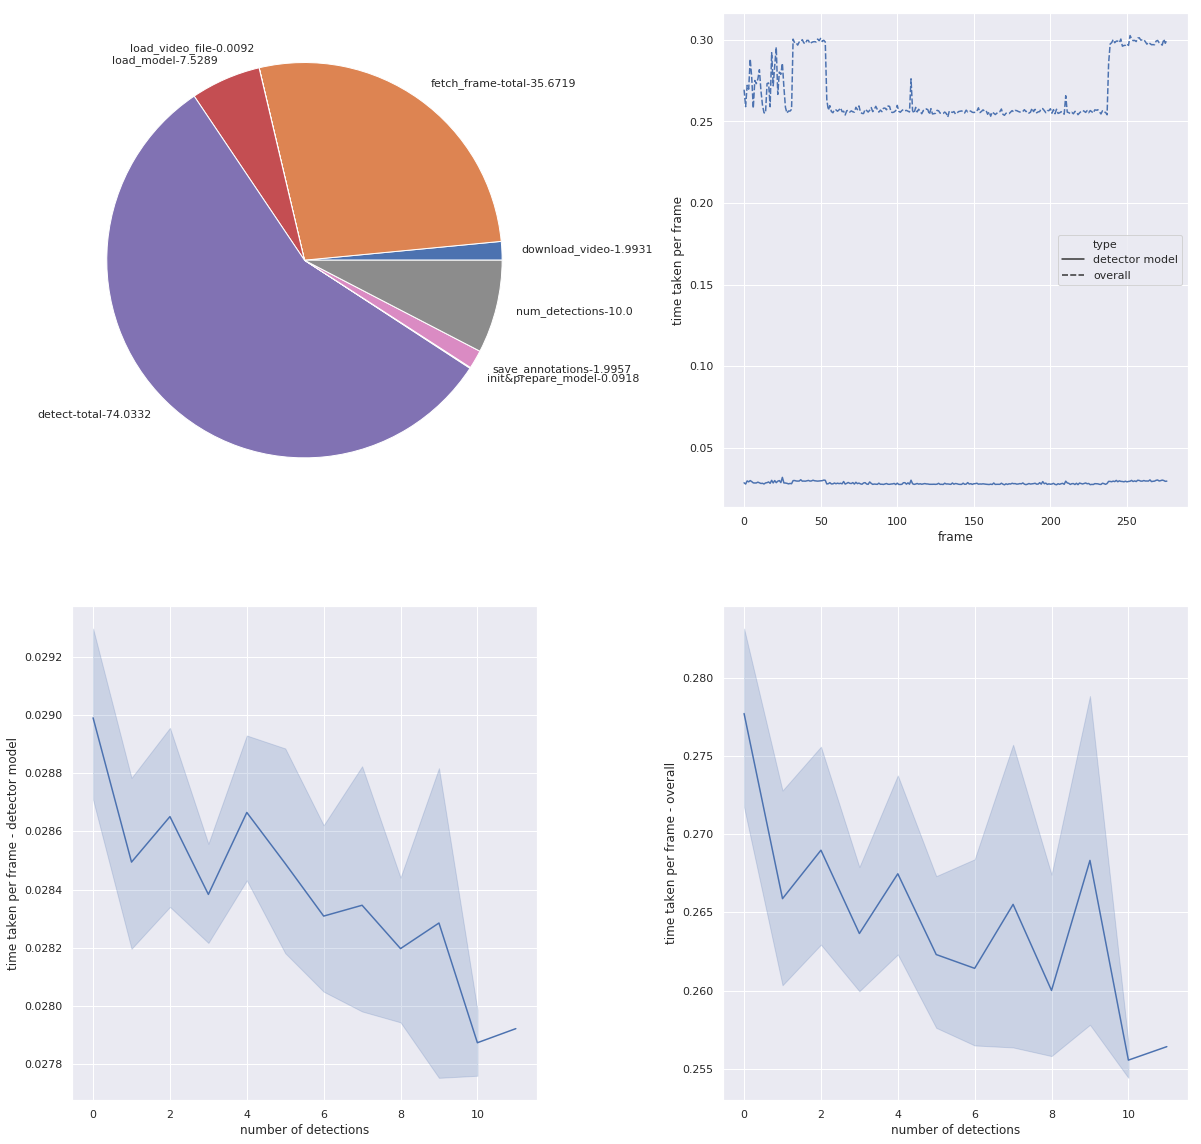

In [126]:
plot_data_for_file(data_ex,ints_ex,ints_dm,file_index = 0)

# Other metrics

In [127]:
print('Index ','\t Filename')
for i in range(len(data_ex)):
    print(data_ex.loc[str(i),'index'],'\t',data_ex.loc[str(i),'input_file'])

Index  	 Filename
0 	 Best Goals Of 2018.mp4
1 	 Best Goals Of 2018.mp4
4 	 Why is 0! = 1.mp4
5 	 Cristiano Ronaldo Goals where Goalkeepers Dont Move.mp4
6 	 Cristiano Ronaldo Goals where Goalkeepers Dont Move.mp4
7 	 Yuvi 6 sixes full HD.mp4
8 	 Yuvi 6 sixes full HD.mp4
9 	 Marc Raibert shows off a close-to-production Spot Mini.mp4
10 	 Marc Raibert shows off a close-to-production Spot Mini.mp4
11 	 Cristiano Ronaldo UCL Goals That Shocked The World.mp4
2 	 Cristiano Ronaldo UCL Goals That Shocked The World.mp4
3 	 Why is 0! = 1.mp4


Text(0.5, 1.0, 'Detection time inside detector model vs video duration')

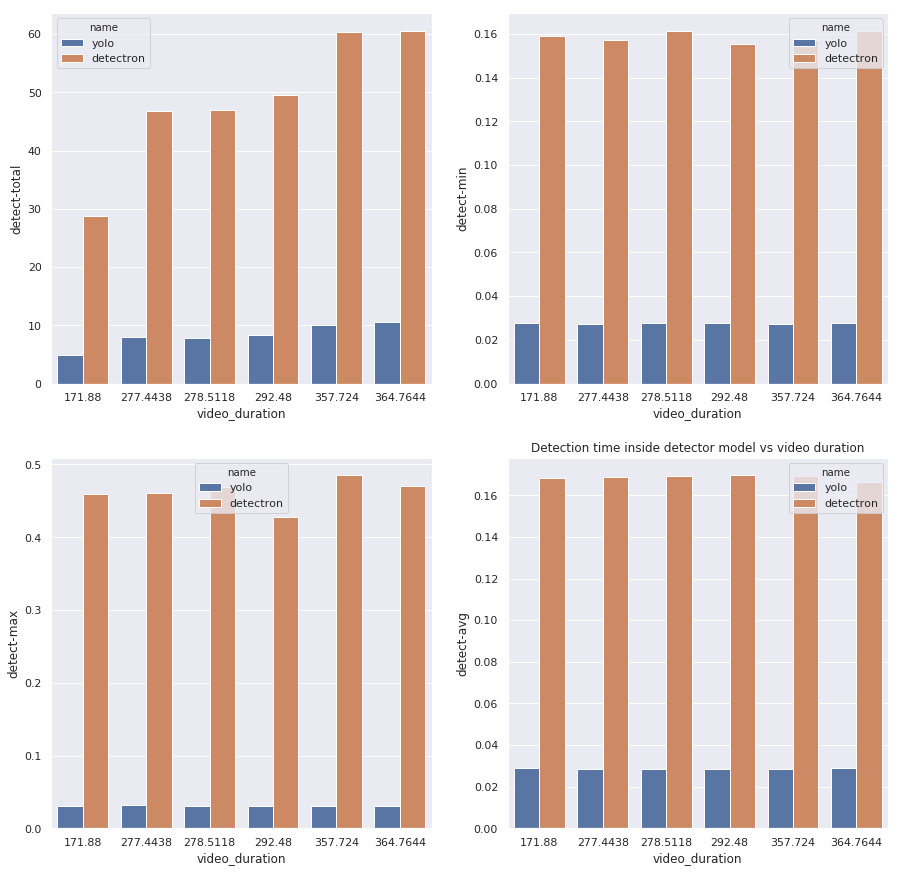

In [128]:
fig, axes = plt.subplots(2,2,figsize=(15,15))
xmetric = ['video_duration','index'][0]
dft = data_dm
sns.barplot(data=dft,x=xmetric,y='detect-total',ax=axes[0,0],hue='name')
sns.barplot(data=dft,x=xmetric,y='detect-min',ax=axes[0,1],hue='name')
sns.barplot(data=dft,x=xmetric,y='detect-max',ax=axes[1,0],hue='name')
sns.barplot(data=dft,x=xmetric,y='detect-avg',ax=axes[1,1],hue='name')

plt.title('Detection time inside detector model vs video duration')
#plt.legend(title='Video file name', loc='lower right', labels=data_ex.loc[:,'input_file'])

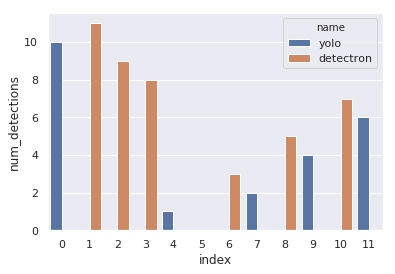

In [129]:
sns.barplot(data=data_ex,x='index',y='num_detections',hue='name')

In [130]:
# from fpdf import FPDF
 
# pdf = FPDF()
# pdf.add_page()
# pdf.set_font("Arial", size=12)
# pdf = FPDF(orientation='P', unit='mm', format='A4')
# pdf.cell(200, 10, txt="Welcome to Python!", ln=1, align="C")
# pdf.output("simple_demo.pdf")

# Report

## Pipeline

Index(['download_video', 'fetch_frame-total', 'load_video_file', 'load_model',
       'detect-total', 'init&prepare_model', 'save_annotations', 'index',
       'num_detections'],
      dtype='object')


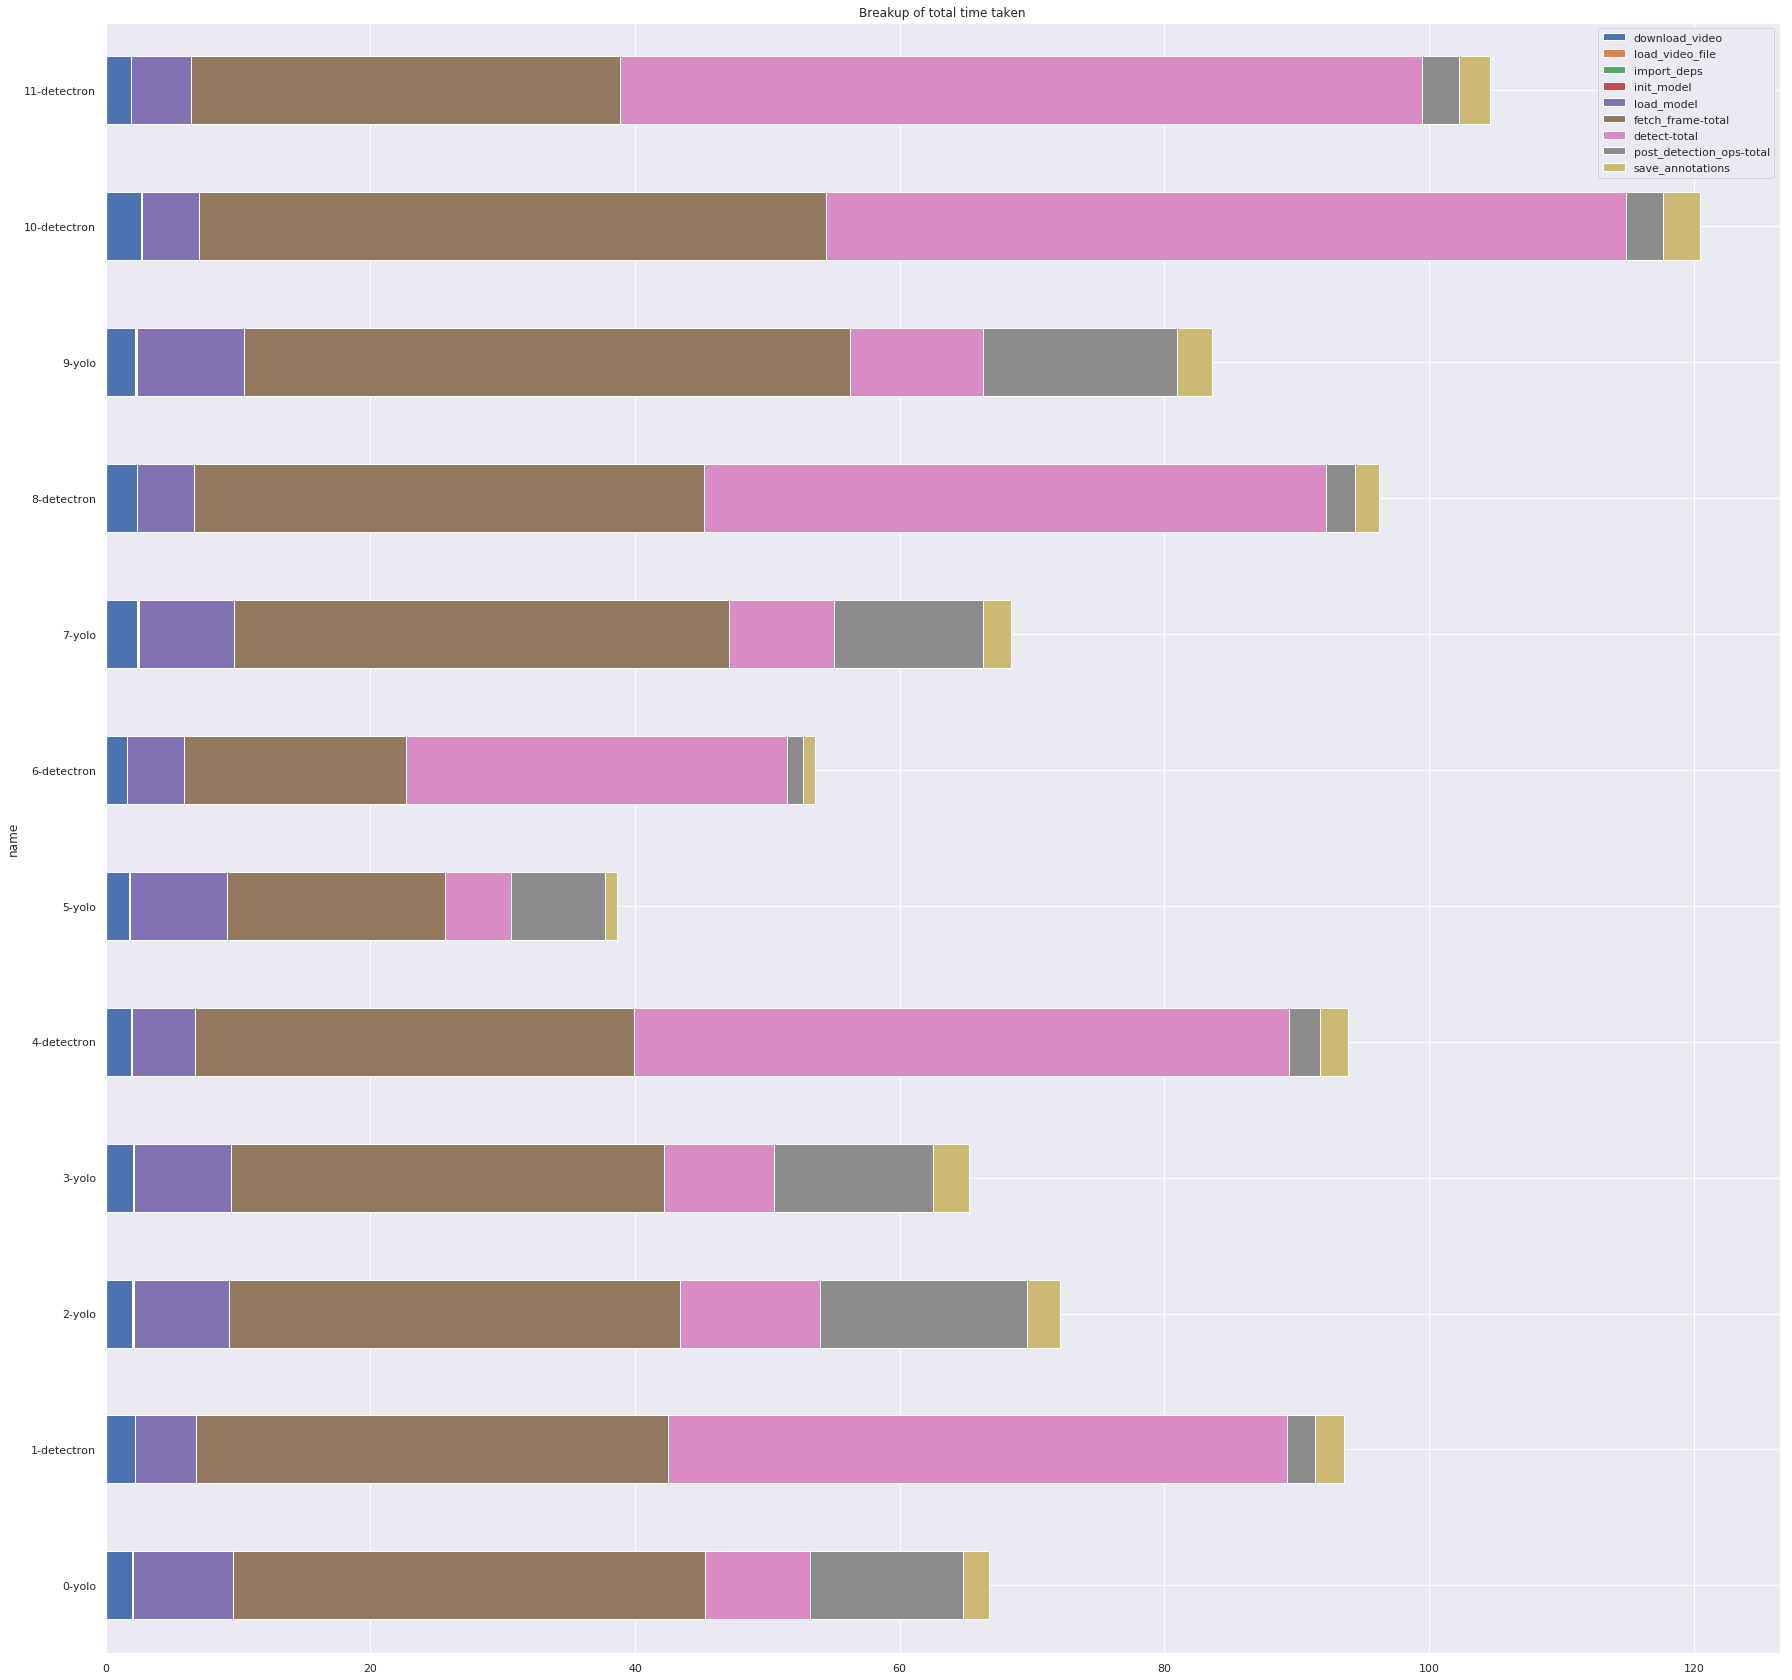

In [131]:
fig1,ax1 = plt.subplots()
dd = data_ex.drop( ['name','input_file','Total_time','video_duration','video_file_size'],axis=1)
dd=drop_cols(dd,['avg','min','max'])
print(dd.columns)
dd = dd[['download_video','load_video_file','fetch_frame-total', 'save_annotations']]#'init&prepare_model','load_model'
dd[['import_deps','init_model','load_model','detect-total','post_detection_ops-total']] = data_dm[['import_deps','init_model','load_model','detect-total','post_detection_ops-total']]


dd = dd[['download_video','load_video_file','import_deps','init_model','load_model','fetch_frame-total','detect-total','post_detection_ops-total','save_annotations']]

dd.index = data_ex.index+'-'+data_ex.name
dd.plot(kind='barh', stacked=True,figsize=(30,2.5*len(dd)),title='Breakup of total time taken',ax=ax1)

' '

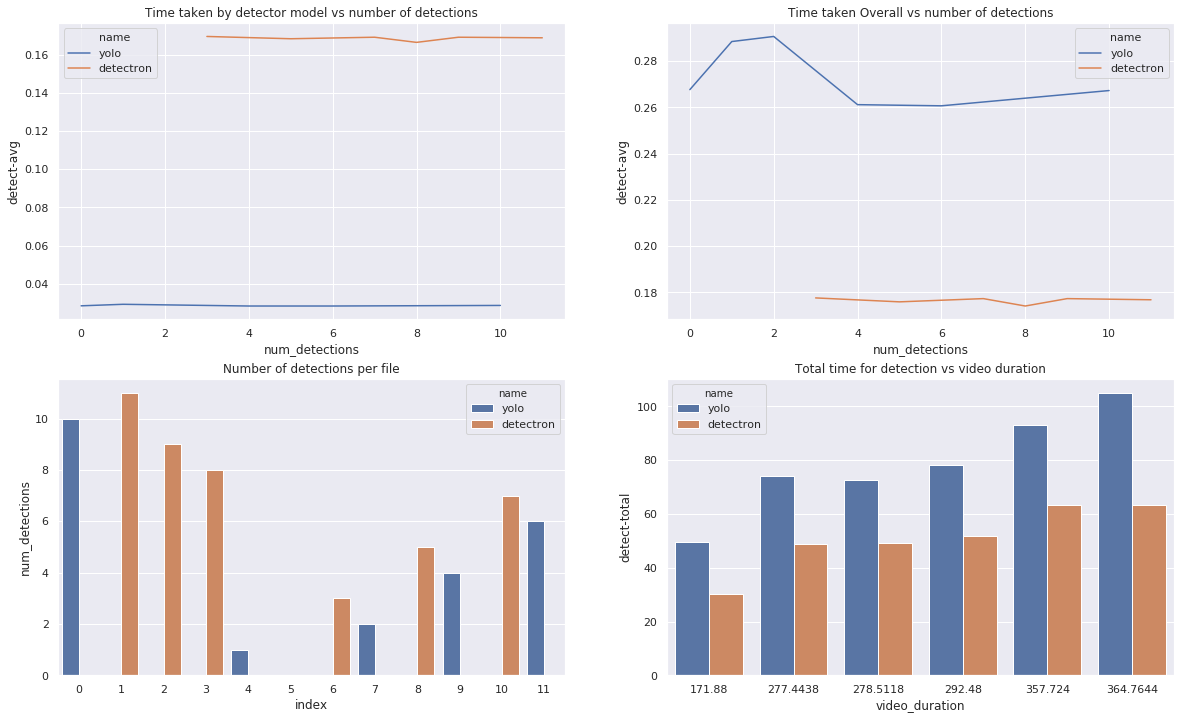

In [132]:
fig2,axs = plt.subplots(2,2,figsize=(20,12))
x,y,hue='num_detections','detect-avg','name'
sns.lineplot(data=data_dm,x=x,y=y,hue=hue,ax=axs[0,0]).set_title('Time taken by detector model vs number of detections')
sns.lineplot(data=data_ex,x=x,y=y,hue=hue,ax=axs[0,1]).set_title('Time taken Overall vs number of detections')
sns.barplot(data=data_dm,x='index',y='num_detections',hue='name',ax=axs[1,0]).set_title('Number of detections per file')
sns.barplot(data=data_ex,y='detect-total',hue='name',x='video_duration',ax=axs[1,1]).set_title('Total time for detection vs video duration')
' '

In [133]:
save_figs_as_pdf([fig1,fig2],'Report.pdf')